# Walmart Recruiting - Store Sales Forecasting

## Importação das Bibliotecas

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

## Carregando os Dados

In [3]:
PATH = './dataset/'
train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')
stores = pd.read_csv(PATH + 'stores.csv')
features = pd.read_csv(PATH + 'features.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Stores shape: {stores.shape}")
print(f"Features shape: {features.shape}")

Train shape: (421570, 5)
Test shape: (115064, 4)
Stores shape: (45, 3)
Features shape: (8190, 12)


## Merge dos Conjuntos

In [4]:
train_df = train.merge(stores, on='Store', how='left')
train_df = train_df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

test_df = test.merge(stores, on='Store', how='left')
test_df = test_df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


## Análise Exploratória de Dados

In [5]:
print("--- Informações do Dataset de Treino ---")
print(train_df.info())

print("\n--- Valore Ausentes no Treino ---")
print(train_df.isnull().sum())

--- Informações do Dataset de Treino ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory

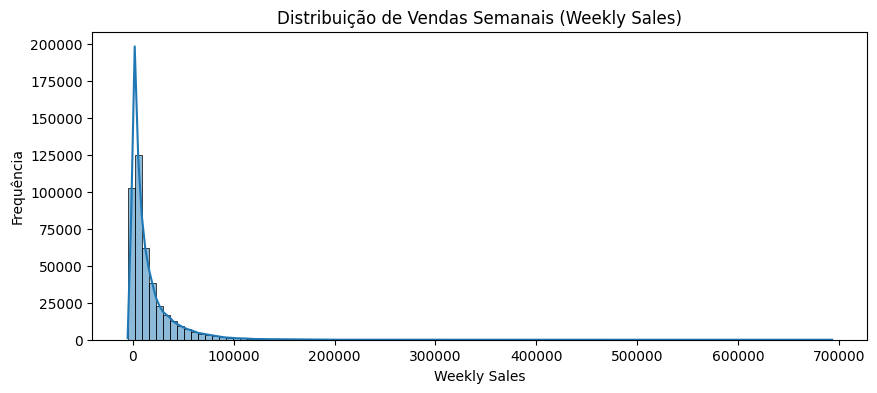

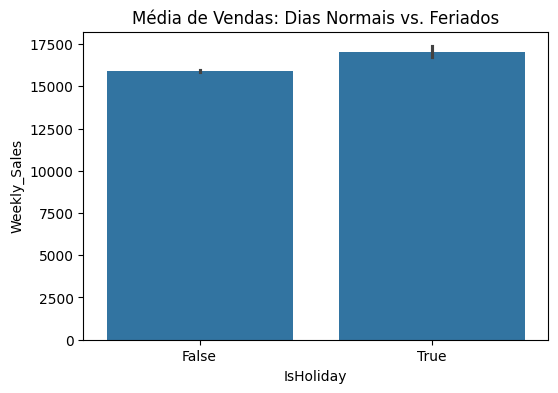

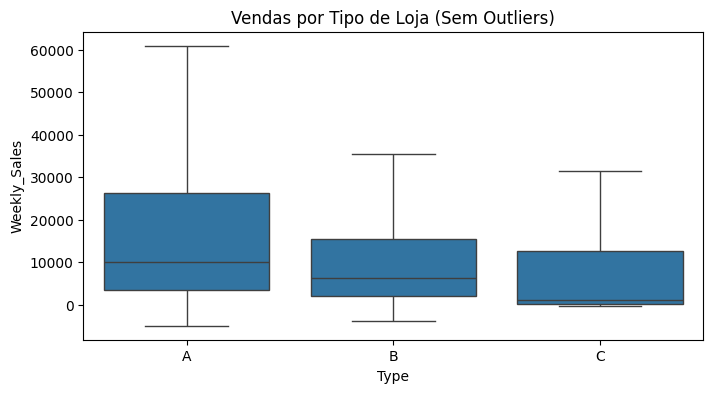

In [6]:
plt.figure(figsize=(10, 4))
sns.histplot(train_df['Weekly_Sales'], bins=100, kde=True)
plt.title('Distribuição de Vendas Semanais (Weekly Sales)')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x='IsHoliday', y='Weekly_Sales')
plt.title('Média de Vendas: Dias Normais vs. Feriados')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=train_df, x='Type', y='Weekly_Sales', showfliers=False)
plt.title('Vendas por Tipo de Loja (Sem Outliers)')
plt.show()

## Pré-Processamento e Feature Engineering

In [ ]:
df_all = pd.concat([train_df, test_df], axis=0, ignore_index=True)

df_all['Date'] = pd.to_datetime(df_all['Date'])
df_all['Year'] = df_all['Date'].dt.year
df_all['Month'] = df_all['Date'].dt.month
df_all['Week'] = df_all['Date'].dt.isocalendar().week.astype(int)
df_all['Day'] = df_all['Date'].dt.day

df_all['Type'] = df_all['Type'].map({'A': 1, 'B': 2, 'C': 3})
df_all['IsHoliday'] = df_all['IsHoliday'].astype(int)

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_all[markdown_cols] = df_all[markdown_cols].fillna(0)

df_all['CPI'] = df_all['CPI'].fillna(df_all['CPI'].median())
df_all['Unemployment'] = df_all['Unemployment'].fillna(df_all['Unemployment'].median())

train_clean = df_all[df_all['Weekly_Sales'].notnull()].copy()
test_clean = df_all[df_all['Weekly_Sales'].isnull()].copy()

print(f"Treino limpo: {train_clean.shape}")
print(f"Teste limpo: {test_clean.shape}")

Treino limpo: (421570, 20)
Teste limpo: (115064, 20)


## Métrica de Avaliação - WMAE

In [8]:
def calculate_wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday == 1, 5, 1)
    wmae = np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)
    return wmae

## Modelagem e Validação Cruzada

In [12]:
# Ignora todos os avisos de depreciação do LightGBM
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='lightgbm')


features_to_use = [
    'Store', 'Dept', 'Type', 'Size', 'IsHoliday',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'Year', 'Month', 'Week', 'Day'
]

X = train_clean[features_to_use]
y = train_clean['Weekly_Sales']
X_test = test_clean[features_to_use]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
wmae_scores = []
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    val_preds = model.predict(X_va)
    score = calculate_wmae(y_va, val_preds, X_va['IsHoliday'])
    wmae_scores.append(score)
    
    print(f"Fold {fold + 1} WMAE: {score:.4f}")
    
    test_preds += model.predict(X_test) / kf.n_splits

print(f"\n---> WMAE Médio da Validação Cruzada: {np.mean(wmae_scores):.4f}")

Fold 1 WMAE: 2756.1356
Fold 2 WMAE: 2697.5540
Fold 3 WMAE: 2701.5222
Fold 4 WMAE: 2741.4416
Fold 5 WMAE: 2708.8879

---> WMAE Médio da Validação Cruzada: 2721.1083


## Importância das Features

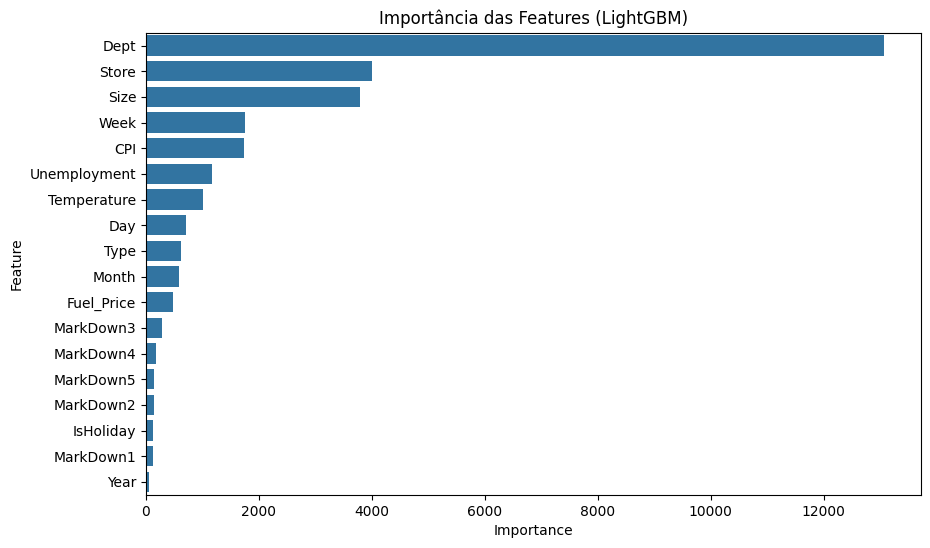

In [13]:
feature_imp = pd.DataFrame({
    'Feature': features_to_use,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp, x='Importance', y='Feature')
plt.title('Importância das Features (LightGBM)')
plt.show()

## Gerando Arquivo de Submissão

In [14]:
submission = pd.DataFrame({
    'Id': test_clean['Store'].astype(str) + '_' + test_clean['Dept'].astype(str) + '_' + test_clean['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Arquivo 'submission.csv' gerado com sucesso!")
submission.head()

Arquivo 'submission.csv' gerado com sucesso!


,Id,Weekly_Sales
421570,1_1_2012-11-02,29623.704447
421571,1_1_2012-11-09,19706.596978
421572,1_1_2012-11-16,20371.919817
421573,1_1_2012-11-23,20212.377593
421574,1_1_2012-11-30,28766.284016
